## This notebook will test using a tensor DNN to try to get similar performance to the paper

Will attempt to get a testing implementation working to try optimising parameters.

In [24]:
import os
import time
from collections.abc import Sized, Iterable

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

#### Configuration

Notes among variables

* Batch normalisation reduces need for dropout highlighted in original paper
* Dropout still appears to help at lower percentage
* Adding depth to DNN much better than adding width in manual testing
* Dropout of first layer is a disaster and I don't know why I thought it would be good

In [33]:

csv_path = "./HIGGS.csv"

# --- feature set -----------------------------------------------------
# 28 columns total. Columns 1-21 are the "low-level" kinematic features
# columns 22-28 are the 7 "high-level" derived features (m_jj ... m_wwbb)
feature_set = "low"               # "all" | "low"

# --- architecture ----------------------------------------------------
# Paper's best: "five-layer" net = 4 hidden x 300 + output
hidden_layers = [300, 300, 300, 300, 300, 300, 300]
# hidden_layers = [600, 600, 600, 600]
# GELU appears best!
act_layer = nn.GELU # nn.ReLU, nn.SiLU nn.Tanh, or possibly nn.GELU

# with no batch normalisation, more dropout is better - 50% better than 20%
# batchnorm enabled with no dropout is significantly better than 50% dropout without batch normalisation
# batch normalisation plus 50% dropout is a slight improvement, but 20% is a bigger improvement
# batch normalisation mitigates the need for dropout and makes a smaller percentage perform better
batchnorm = True                  # stabiliser see paper https://arxiv.org/abs/1502.03167 - nn.BatchNorm1d

dropout = 0.2                     # paper applied 50% dropout to the TOP hidden layer
initial_dropout = 0.0


# --- optimisation ----------------------------------------------------
epochs = 100                       # 100 assuming we will reach patience limit prior
batch_size = 8192                 # big batches keep the GPU busy; paper used 100 (2011 GPU)
# max_lr = 0.003                     # OneCycle peak LR for AdamW
max_lr = 0.005                     # OneCycle peak LR for AdamW
weight_decay = 0.00001               # matches the paper's L2 coefficient
label_smoothing = 0.0             # try 0.01-0.05 if the net overfits

# --- engineering -----------------------------------------------------
amp = True                        # bfloat16 autocast
compile = True                    # torch.compile fuses kernels; big speedup, falls back if it fails
keep_data_on_gpu = True
early_stop_patience = 6           # stop if val AUC hasn't improved for this many epochs
seed = 1337

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Read and split the data

In [ ]:

data = pd.read_csv(csv_path, header=None, dtype=np.float32)

arr = data.to_numpy()


In [34]:
y = arr[:, 0].astype(np.int8)      # first column = label
X = arr[:, 1:].astype(np.float32)  # remaining 28 columns = features

# Select the feature subset (mirrors the paper's three experiments).
if feature_set == "low":
    X = X[:, :21]                  # 21 low-level kinematic features

X_train, X_val1, y_train, y_val1 = train_test_split(X, y, test_size=0.0909090909, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val1, y_val1, test_size=0.5, random_state=42)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)


# X_train_small, X_val1_small, y_train_small, y_val1_small = train_test_split(X_small, y_small, test_size=0.0909090909, random_state=42)
# X_val_small, X_test_small, y_val_small, y_test_small = train_test_split(X_val1_small, y_val1_small, test_size=0.5, random_state=42)

(10000000, 21)
(500000, 21)
(500000, 21)
(10000000,)
(500000,)
(500000,)


#### Model class

Creates the DNN

In [29]:

class HiggsMLP(nn.Module):

    def __init__(self, in_dim: int):
        super().__init__()

        layers = []
        prev = in_dim
        n_hidden = len(hidden_layers)
        is_first = initial_dropout > 0
        for i, width in enumerate(hidden_layers):
            layers.append(nn.Linear(prev, width))
            if batchnorm:
                layers.append(nn.BatchNorm1d(width))
            layers.append(act_layer())
            if is_first:
                is_first = False
                layers.append(nn.Dropout(initial_dropout))
            is_last_hidden = (i == n_hidden - 1)
            if dropout > 0 and is_last_hidden:
                layers.append(nn.Dropout(dropout))
            prev = width

        layers.append(nn.Linear(prev, 1))    # single logit for binary classification
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)        # shape [B] to match the label vector

# No-grad - use for inference to reduce memory
@torch.no_grad()
def compute_auc(model, X_gpu, y_np, batch: int = 65536):
    model.eval()
    probs = []
    for i in range(0, len(X_gpu), batch):
        logits = model(X_gpu[i:i + batch])
        probs.append(torch.sigmoid(logits).float().cpu().numpy())
    return roc_auc_score(y_np, np.concatenate(probs))

#### Train

Method to use the above class to train a single model

Notes:

* Stopping after 6 no-improvement epochs
* Configured for up to 100 epochs, usually about 30 occur
* OneCycleLR needs to be configured with a pct_start of 0.1 to ensure we start decaying earlier so the reduced learning rate can help approach optimum

train=10,000,000  val=500,000  test=500,000  features=21
torch.compile: enabled
epoch  1/100  loss=0.5864  val_auc=0.7829  lr=3.17e-04  (6.1s)
epoch  2/100  loss=0.5407  val_auc=0.8118  lr=6.58e-04  (2.0s)
epoch  3/100  loss=0.5104  val_auc=0.8351  lr=1.19e-03  (2.0s)
epoch  4/100  loss=0.4852  val_auc=0.8511  lr=1.86e-03  (2.0s)
epoch  5/100  loss=0.4694  val_auc=0.8586  lr=2.60e-03  (2.0s)
epoch  6/100  loss=0.4590  val_auc=0.8647  lr=3.34e-03  (2.0s)
epoch  7/100  loss=0.4516  val_auc=0.8662  lr=4.01e-03  (2.0s)
epoch  8/100  loss=0.4459  val_auc=0.8710  lr=4.54e-03  (2.0s)
epoch  9/100  loss=0.4411  val_auc=0.8738  lr=4.88e-03  (2.0s)
epoch 10/100  loss=0.4367  val_auc=0.8753  lr=5.00e-03  (2.0s)
epoch 11/100  loss=0.4324  val_auc=0.8778  lr=5.00e-03  (2.0s)
epoch 12/100  loss=0.4289  val_auc=0.8793  lr=4.99e-03  (2.0s)
epoch 13/100  loss=0.4258  val_auc=0.8799  lr=4.99e-03  (2.0s)
epoch 14/100  loss=0.4232  val_auc=0.8812  lr=4.98e-03  (2.0s)
epoch 15/100  loss=0.4208  val_auc=0.8

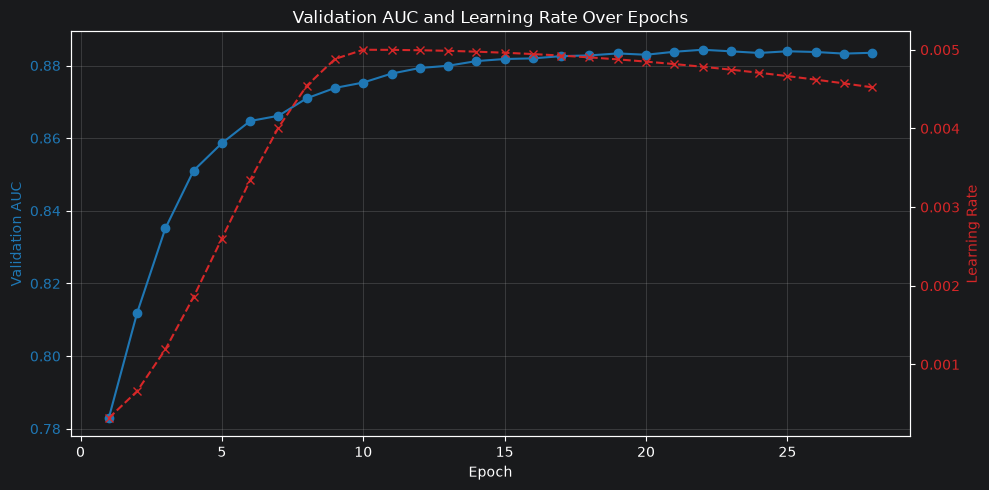

In [30]:
torch.manual_seed(seed)
np.random.seed(seed)
# TF32 matmuls: free accuracy-for-speed trade on NVIDIA GPUs for fp32 ops.
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# ---- data -----------------------------------------------------------

# Xtr, ytr, Xva, yva, Xte, yte = make_splits(X, y)
# Xtr, Xva, Xte = standardize(Xtr, Xva, Xte)
print(f"train={len(X_train):,}  val={len(X_val):,}  test={len(X_test):,}  features={X_train.shape[1]}")

# Move tensors to the GPU ONCE. With ~10M x 28 floats (~1.1 GB) the whole
# training set lives in the 16 GB of VRAM, so each step is a pure-GPU index
# slice -- no CPU->GPU copy per batch, which is otherwise the #1 bottleneck.
# (If your data did NOT fit in VRAM, you'd instead use a DataLoader with
#  pin_memory=True, num_workers>0, and .to(DEVICE, non_blocking=True).)
to_gpu = keep_data_on_gpu
Xtr_t = torch.tensor(X_train, device=DEVICE if to_gpu else "cpu")
ytr_t = torch.tensor(y_train, dtype=torch.float32, device=DEVICE if to_gpu else "cpu")
Xva_t = torch.tensor(X_val, device=DEVICE)
Xte_t = torch.tensor(X_test, device=DEVICE)

# ---- model / loss / optimiser --------------------------------------
model = HiggsMLP(in_dim=X_train.shape[1]).to(DEVICE)

if compile:
    try:
        model = torch.compile(model)
        print("torch.compile: enabled")
    except Exception as e:
        print(f"torch.compile failed ({e}); continuing uncompiled")

# BCEWithLogitsLoss = sigmoid + binary cross-entropy, fused & numerically stable.
loss_fn = nn.BCEWithLogitsLoss()
# AdamW is the modern default (decoupled weight decay)
opt = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
# Basic, similar to original paper
# opt = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9, weight_decay=1e-5)

n_train = len(Xtr_t)
steps_per_epoch = (n_train + batch_size - 1) // batch_size
# OneCycle: LR warms up then anneals within the run. Robust, fast-converging
# schedule for MLPs; a modern replacement for the paper's slow manual decay.
sched = torch.optim.lr_scheduler.OneCycleLR(
    opt, max_lr=max_lr,
    epochs=epochs, steps_per_epoch=steps_per_epoch,
    pct_start=0.1,  # was having an issue where patience would run out before lr would decay - want to keep training for up to 100 but likely will never go that long
)

# bfloat16 autocast: half-precision math on the GPU, ~2x throughput. bf16
# (unlike fp16) has enough dynamic range that NO GradScaler is needed.
amp_ctx = (torch.autocast("cuda", dtype=torch.bfloat16)
           if amp and DEVICE.type == "cuda"
           else torch.autocast("cuda", enabled=False))

# 1. Initialize lists to store metrics before the loop
history = {
    'epoch': [],
    'val_auc': [],
    'lr': []
}

# ---- epoch loop -----------------------------------------------------
best_auc, best_state, epochs_no_improve = 0.0, None, 0
for epoch in range(1, epochs + 1):
    model.train()
    t0 = time.perf_counter()
    perm = torch.randperm(n_train, device=Xtr_t.device)  # fresh shuffle each epoch
    running = 0.0
    for i in range(0, n_train, batch_size):
        idx = perm[i:i + batch_size]
        xb = Xtr_t[idx]
        yb = ytr_t[idx]
        if not to_gpu:                       # only needed if data is on CPU
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)

        opt.zero_grad(set_to_none=True)      # set_to_none is slightly faster than zeroing
        with amp_ctx:
            logits = model(xb)
            loss = loss_fn(logits, yb)
        loss.backward()
        opt.step()
        sched.step()                         # OneCycle steps PER BATCH, not per epoch
        running += loss.item() * len(idx)

    val_auc = compute_auc(model, Xva_t, y_val)
    dt = time.perf_counter() - t0

    current_lr = sched.get_last_lr()[0]

    history['epoch'].append(epoch)
    history['val_auc'].append(val_auc)
    history['lr'].append(current_lr)

    print(f"epoch {epoch:2d}/{epochs}  loss={running / n_train:.4f}  "
          f"val_auc={val_auc:.4f}  lr={current_lr:.2e}  ({dt:.1f}s)")

    # Early stopping: keep the best-on-validation weights, stop if stalled.
    if val_auc > best_auc + 0.0001:
        best_auc = val_auc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stop_patience:
            print(f"early stopping (no val improvement for {early_stop_patience} epochs)")
            break

# ---- final test evaluation -----------------------------------------
if best_state is not None:
    model.load_state_dict(best_state)        # restore best-validation weights
test_auc = compute_auc(model, Xte_t, y_test)
print("\n" + "=" * 60)
print(f"BEST VAL AUC : {best_auc:.4f}")
print(f"TEST AUC     : {test_auc:.4f}")
print("=" * 60)

# 3. Plot the collected data after the loop finishes
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Validation AUC on the left Y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Validation AUC', color=color1)
ax1.plot(history['epoch'], history['val_auc'], color=color1, marker='o', label='Val AUC')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Create a second Y-axis that shares the same X-axis
ax2 = ax1.twinx()

# Plot Learning Rate on the right Y-axis
color2 = 'tab:red'
ax2.set_ylabel('Learning Rate', color=color2)
ax2.plot(history['epoch'], history['lr'], color=color2, marker='x', linestyle='--', label='LR')
ax2.tick_params(axis='y', labelcolor=color2)

# Optional: Add a title and adjust layout so labels don't get cut off
plt.title('Validation AUC and Learning Rate Over Epochs')
fig.tight_layout()
plt.show()